In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


7 Exercise.



Implement an End to End CNN Model for Image Classification Task.


Task 1: Data Understanding and Visualization:


Download the Provided Data and Complete the following task.



1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:
• Get the list of class directories from the train folder.
• Select one image randomly from each class.
• Display the images in a grid format with two rows using matplotlib.

In [3]:
import os

train_dir = "/content/drive/MyDrive/AIML(week5)/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AIML(week5)/FruitinAmazon/FruitinAmazon/test"

Classes: ['tucuma', 'guarana', 'pupunha', 'graviola', 'cupuacu', 'acai']


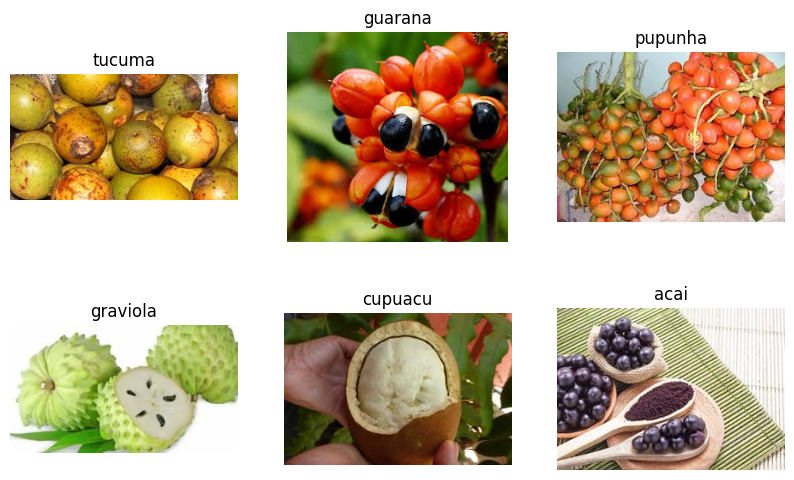

In [5]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)
print("Classes:", classes)

images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    files_in_class = os.listdir(class_path)
    if not files_in_class:
        print(f"Warning: No files found in {class_path}, skipping.")
        continue

    img_name = random.choice(files_in_class)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

if images:
    plt.figure(figsize=(10,6))
    num_cols = (len(images) + 1) // 2
    for i in range(len(images)):
        plt.subplot(2, num_cols, i+1)
        plt.imshow(images[i])
        plt.title(labels[i])
        plt.axis("off")

    plt.show()
else:
    print("No images were loaded for visualization.")

• What did you Observe?


Dataset contains multiple fruit classes. These classes have different image variations such as lighting, angles, and backgrounds. This diversity helps improve model generalization.


2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”

In [6]:
from PIL import Image

corrupted = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found")

No Corrupted Images Found


Task 2: Loading and Preprocessing Image Data in keras:



This part gets pictures ready by pulling them from a folder and shaping them for use. This tool pulls pictures from folders, each named after a category it stands for. Resizing happens first, then grouping into sets plus adjusting pixel values follows. Each step runs quietly behind, shaping data without fuss
Pictures come in through a single method that handles both training and check sets. This approach works for loading either type without changes.

Load & Preprocess Data

In [7]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

Load training dataset

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


Load validation dataset

In [9]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


Normalize data

In [10]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Task 3 - Implement a CNN with

Build CNN Model

In [15]:
from tensorflow.keras import layers, models

num_classes = len(classes)

model = models.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

Task 4: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam)

Compile Model

In [16]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Train the Model
Model Training


Train Model

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint("best_model.h5", save_best_only=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    batch_size=16,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.3681 - loss: 1.4134

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 850ms/step - accuracy: 0.4167 - loss: 1.3667 - val_accuracy: 0.4444 - val_loss: 1.2720
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.4288 - loss: 1.2499

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 639ms/step - accuracy: 0.4583 - loss: 1.2166 - val_accuracy: 0.8889 - val_loss: 0.7715
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 0.6528 - loss: 0.9645 - val_accuracy: 0.7222 - val_loss: 0.9440
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 428ms/step - accuracy: 0.8056 - loss: 0.8061 - val_accuracy: 0.5556 - val_loss: 1.1317
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8553 - loss: 0.5847

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.8472 - loss: 0.5961 - val_accuracy: 0.8889 - val_loss: 0.4617
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 436ms/step - accuracy: 0.7917 - loss: 0.4699 - val_accuracy: 0.7222 - val_loss: 0.6703
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 675ms/step - accuracy: 0.9028 - loss: 0.3244 - val_accuracy: 0.5556 - val_loss: 1.1155
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.8947 - loss: 0.3516

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 854ms/step - accuracy: 0.9028 - loss: 0.3193 - val_accuracy: 0.8889 - val_loss: 0.3776
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 423ms/step - accuracy: 0.9722 - loss: 0.1627 - val_accuracy: 0.7778 - val_loss: 0.6433
Epoch 10/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8796 - loss: 0.2893

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 513ms/step - accuracy: 0.8889 - loss: 0.2587 - val_accuracy: 0.8333 - val_loss: 0.3511
Epoch 11/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 0.9861 - loss: 0.0792 - val_accuracy: 0.6667 - val_loss: 0.6838
Epoch 12/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.9653 - loss: 0.1240

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 507ms/step - accuracy: 0.9583 - loss: 0.1238 - val_accuracy: 0.9444 - val_loss: 0.2243
Epoch 13/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.9861 - loss: 0.0434 - val_accuracy: 0.9444 - val_loss: 0.3534
Epoch 14/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 819ms/step - accuracy: 0.9861 - loss: 0.0988 - val_accuracy: 0.9444 - val_loss: 0.3635
Epoch 15/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 636ms/step - accuracy: 1.0000 - loss: 0.0336 - val_accuracy: 0.8333 - val_loss: 0.3254
Epoch 16/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 430ms/step - accuracy: 1.0000 - loss: 0.0320 - val_accuracy: 0.8333 - val_loss: 0.4806
Epoch 17/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 434ms/step - accuracy: 0.9722 - loss: 0.0597 - val_accuracy: 0.8889 - val_loss: 0.4336
Epoch 18/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 496ms/step - accuracy: 1.0000 - loss: 0.0239 - val_accuracy: 0.8889 - val_loss: 0.3764
Epoch 19/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 427ms/step - accuracy: 1.0000 - loss: 0.0199 - val_accuracy: 0.8333 - val_loss: 0.2

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 534ms/step - accuracy: 1.0000 - loss: 0.0072 - val_accuracy: 0.9444 - val_loss: 0.1692
Epoch 21/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 1.0000 - loss: 0.0050

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 661ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 0.9444 - val_loss: 0.1472
Epoch 22/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 758ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.9444 - val_loss: 0.1483
Epoch 23/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 431ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.9444 - val_loss: 0.1631
Epoch 24/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 0.9444 - val_loss: 0.1924
Epoch 25/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 0.8889 - val_loss: 0.2177
Epoch 26/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 426ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8333 - val_loss: 0.2309
Epoch 27/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 581ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8333 - val_loss: 0.2348
Epoch 28/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 435ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8333 - val_loss: 0.2

Plot Accuracy & Loss

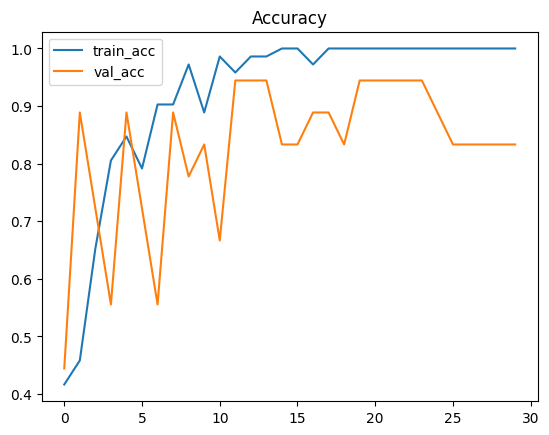

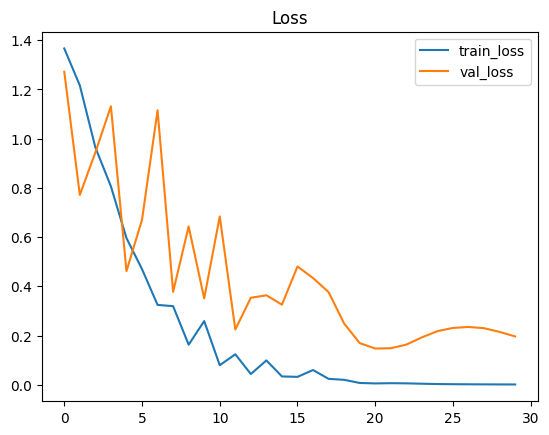

In [19]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

Task 6: Evaluate the Model

Model Evaluation

• After training, evaluate

In [20]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128,128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.7333 - loss: 0.7495
Test Accuracy: 0.7333333492279053


Task 7: Save and Load the Model
Model Saving and Loading






Save & Load Model

In [21]:
model.save("fruit_model.h5")

# Load again
from tensorflow.keras.models import load_model

loaded_model = load_model("fruit_model.h5")

loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step - accuracy: 0.7333 - loss: 0.7495


[0.7495192289352417, 0.7333333492279053]

Task 8: Predictions and Classification Report
Making Predictions




Classification Report

In [22]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
              precision    recall  f1-score   support

      tucuma       0.62      1.00      0.77         5
     guarana       0.50      0.80      0.62         5
     pupunha       1.00      0.80      0.89         5
    graviola       0.75      0.60      0.67         5
     cupuacu       1.00      0.80      0.89         5
        acai       1.00      0.40      0.57         5

    accuracy                           0.73        30
   macro avg       0.81      0.73      0.73        30
weighted avg       0.81      0.73      0.73        30

